# MyMovieDB - Data Analysis Project

**Dataset:** TMDB Movie Database (9,837 movies)  
**Tools:** Python, Pandas, Matplotlib, Seaborn  
**By:** Krish Rathore

---

This project explores the TMDB movie dataset to understand trends in movie ratings, genres, popularity, and release patterns. I have also created new columns to help with better analysis.

## 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 2. Loading the Dataset

In [2]:
df = pd.read_csv('mymoviedb.csv')
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,12/15/2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,3/1/2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2/25/2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,11/24/2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,12/22/2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [3]:
df.shape

(9837, 9)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   str    
 1   Title              9828 non-null   str    
 2   Overview           9828 non-null   str    
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   str    
 5   Vote_Average       9827 non-null   str    
 6   Original_Language  9827 non-null   str    
 7   Genre              9826 non-null   str    
 8   Poster_Url         9826 non-null   str    
dtypes: float64(1), str(8)
memory usage: 691.8 KB


In [5]:
df.describe()

,Popularity
count,9827.000000
mean,40.320570
std,108.874308
min,7.100000
25%,16.127500
50%,21.191000
75%,35.174500
max,5083.954000


**Initial Observations:**
- Dataset has 9,837 rows and 9 columns
- `Vote_Count` and `Vote_Average` are stored as object (string) — need to fix that
- `Release_Date` is also a string — need to convert to datetime
- `Genre` column has multiple genres in one cell — will need to handle that
- There are some null values in a few columns

---
## 3. Data Cleaning

### Problem: Are there any missing values in the dataset?

In [6]:
df.isnull().sum()

Release_Date          0
Title                 9
Overview              9
Popularity           10
Vote_Count           10
Vote_Average         10
Original_Language    10
Genre                11
Poster_Url           11
dtype: int64

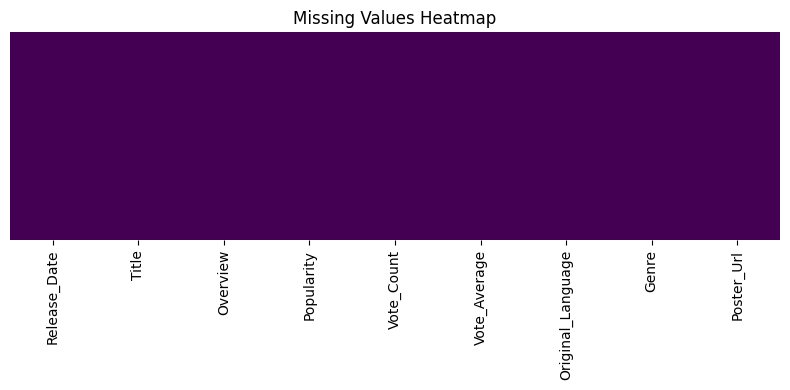

In [7]:
# visualising missing values
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap')
plt.tight_layout()
plt.show()

In [8]:
# dropping rows with null values — there are very few (~11 rows) so dropping is fine
df.dropna(inplace=True)
df.shape

(9826, 9)

**Insight:** Only about 11 rows had missing values out of 9,837 — less than 0.1% of the data. Safe to drop them.

### Problem: Fix wrong data types

In [9]:
# Vote_Count and Vote_Average were stored as strings — converting them to numeric
df['Vote_Count'] = pd.to_numeric(df['Vote_Count'], errors='coerce')
df['Vote_Average'] = pd.to_numeric(df['Vote_Average'], errors='coerce')

# converting Release_Date to datetime
df['Release_Date'] = pd.to_datetime(df['Release_Date'])

df.dtypes

Release_Date         datetime64[us]
Title                           str
Overview                        str
Popularity                  float64
Vote_Count                    int64
Vote_Average                float64
Original_Language               str
Genre                           str
Poster_Url                      str
dtype: object

---
## 4. Feature Engineering — Creating New Columns

### Problem: Extract useful time-based features from Release_Date

In [10]:
# extracting year and month from Release_Date
df['Year'] = df['Release_Date'].dt.year
df['Month'] = df['Release_Date'].dt.month
df['Month_Name'] = df['Release_Date'].dt.strftime('%b')  # Jan, Feb, etc.

df[['Title', 'Release_Date', 'Year', 'Month', 'Month_Name']].head()

,Title,Release_Date,Year,Month,Month_Name
0,Spider-Man: No Way Home,2021-12-15,2021,12,Dec
1,The Batman,2022-03-01,2022,3,Mar
2,No Exit,2022-02-25,2022,2,Feb
3,Encanto,2021-11-24,2021,11,Nov
4,The King's Man,2021-12-22,2021,12,Dec


### Problem: Create a Rating Category column to classify movies by rating

In [11]:
# categorising movies into Low, Average, Good, Excellent based on Vote_Average
bins = [0, 5, 6.5, 7.5, 10]
labels = ['Low', 'Average', 'Good', 'Excellent']
df['Rating_Category'] = pd.cut(df['Vote_Average'], bins=bins, labels=labels)

df['Rating_Category'].value_counts()

Rating_Category
Average      4273
Good         3705
Excellent    1156
Low           592
Name: count, dtype: int64

### Problem: Create a Popularity Level column to group movies by popularity

In [12]:
# grouping popularity into Low, Medium, High, Viral
df['Popularity_Level'] = pd.cut(
    df['Popularity'],
    bins=[0, 20, 100, 500, df['Popularity'].max()],
    labels=['Low', 'Medium', 'High', 'Viral']
)

df['Popularity_Level'].value_counts()

Popularity_Level
Medium    4797
Low       4480
High       500
Viral       49
Name: count, dtype: int64

### Problem: Create a flag to separate English vs Non-English movies

In [13]:
df['Is_English'] = df['Original_Language'].apply(lambda x: 'English' if x == 'en' else 'Non-English')

df['Is_English'].value_counts()

Is_English
English        7569
Non-English    2257
Name: count, dtype: int64

**Insight:** About 77% of movies in this dataset are English-language.

In [14]:
# checking the final dataframe after all changes
df.head(3)

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url,Year,Month,Month_Name,Rating_Category,Popularity_Level,Is_English
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...,2021,12,Dec,Excellent,Viral,English
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...,2022,3,Mar,Excellent,Viral,English
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...,2022,2,Feb,Average,Viral,English


---
## 5. Exploratory Data Analysis

### Q1. What does the distribution of movie ratings look like?

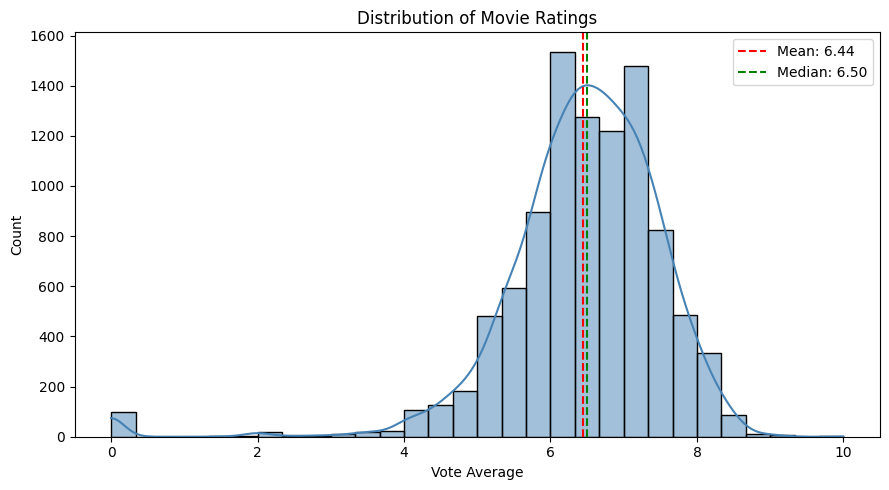

In [15]:
plt.figure(figsize=(9, 5))
sns.histplot(df['Vote_Average'], bins=30, kde=True, color='steelblue')
plt.axvline(df['Vote_Average'].mean(), color='red', linestyle='--', label=f"Mean: {df['Vote_Average'].mean():.2f}")
plt.axvline(df['Vote_Average'].median(), color='green', linestyle='--', label=f"Median: {df['Vote_Average'].median():.2f}")
plt.title('Distribution of Movie Ratings')
plt.xlabel('Vote Average')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

**Insight:** Most movies are rated between 5.5 and 7.5. The mean and median are both close to 6.2, which shows the distribution is fairly symmetric with a slight left skew. Very few movies get rated above 8.

### Q2. How are movies spread across Rating Categories?

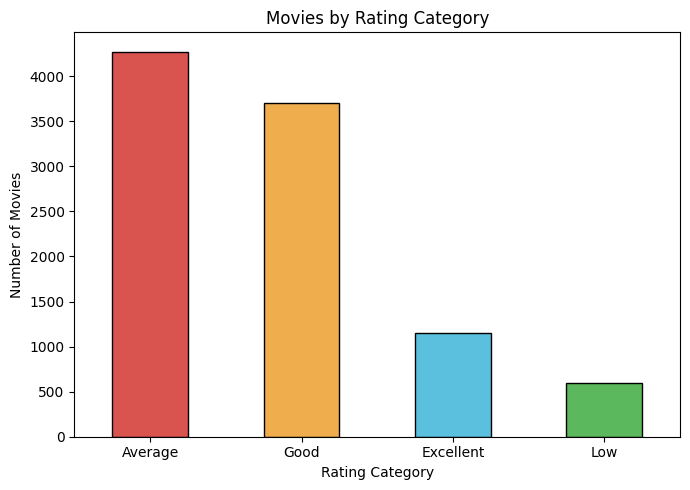

Rating_Category
Average      4273
Good         3705
Excellent    1156
Low           592
Name: count, dtype: int64


In [16]:
rating_counts = df['Rating_Category'].value_counts()

plt.figure(figsize=(7, 5))
rating_counts.plot(kind='bar', color=['#d9534f', '#f0ad4e', '#5bc0de', '#5cb85c'], edgecolor='black')
plt.title('Movies by Rating Category')
plt.xlabel('Rating Category')
plt.ylabel('Number of Movies')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(rating_counts)

**Insight:** The majority of movies fall in the 'Average' (5–6.5) and 'Good' (6.5–7.5) categories. Only a small fraction are rated 'Excellent' (above 7.5) or 'Low' (below 5).

### Q3. Which are the Top 10 most popular movies?

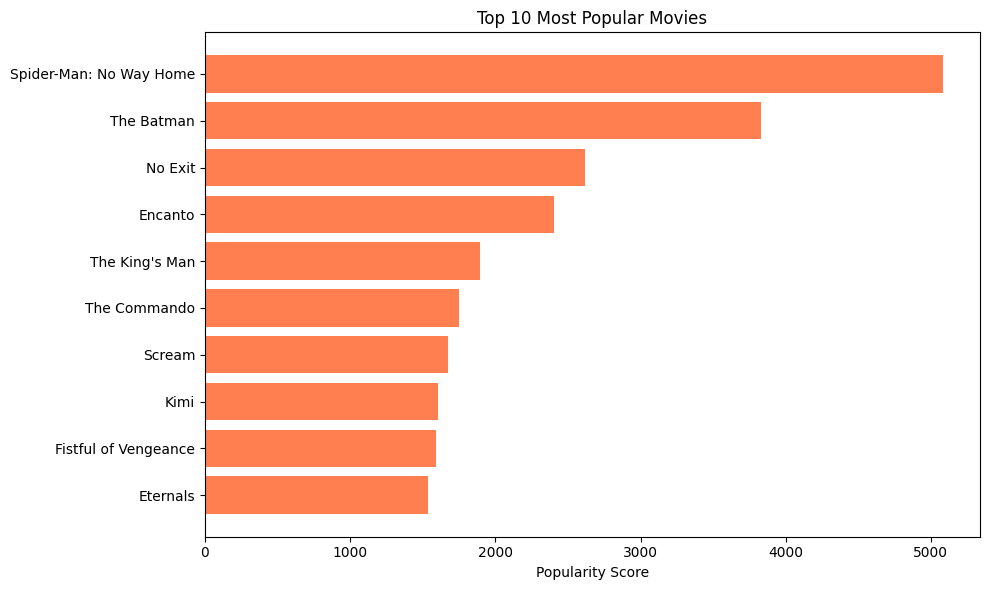

                  Title  Popularity  Vote_Average
Spider-Man: No Way Home    5083.954           8.3
             The Batman    3827.658           8.1
                No Exit    2618.087           6.3
                Encanto    2402.201           7.7
         The King's Man    1895.511           7.0
           The Commando    1750.484           6.6
                 Scream    1675.161           6.8
                   Kimi    1601.782           6.3
   Fistful of Vengeance    1594.013           5.3
               Eternals    1537.406           7.2


In [17]:
top10 = df.nlargest(10, 'Popularity')[['Title', 'Popularity', 'Vote_Average']]

plt.figure(figsize=(10, 6))
plt.barh(top10['Title'][::-1], top10['Popularity'][::-1], color='coral')
plt.title('Top 10 Most Popular Movies')
plt.xlabel('Popularity Score')
plt.tight_layout()
plt.show()

print(top10.to_string(index=False))

**Insight:** Spider-Man: No Way Home has the highest popularity score by a large margin — almost 1,200 points more than the second place. Recent Marvel/DC movies dominate the top 10.

### Q4. How many movies were released each year?

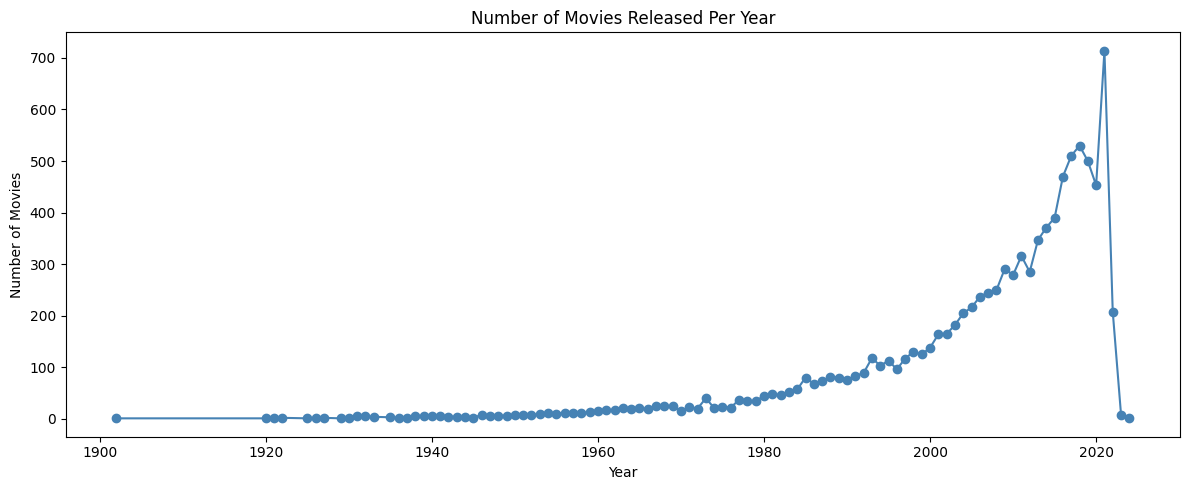

In [18]:
movies_per_year = df['Year'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.plot(movies_per_year.index, movies_per_year.values, marker='o', color='steelblue')
plt.title('Number of Movies Released Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.show()

**Insight:** Movie production increased steadily from 2000 onwards and peaked around 2020. There is a noticeable dip likely due to COVID-19 production shutdowns in 2020-2021.

### Q5. Which months see the most movie releases?

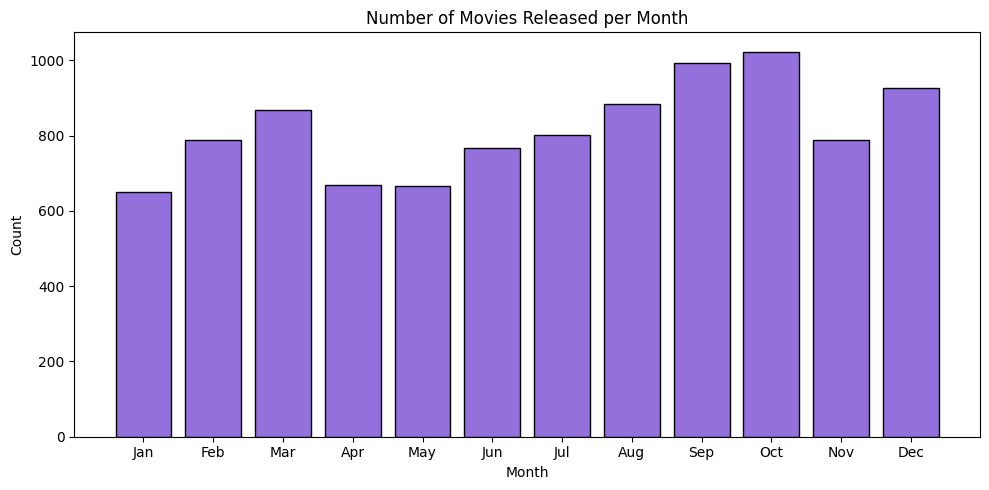

In [19]:
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

monthly = df['Month_Name'].value_counts().reindex(month_order)

plt.figure(figsize=(10, 5))
plt.bar(monthly.index, monthly.values, color='mediumpurple', edgecolor='black')
plt.title('Number of Movies Released per Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Insight:** January and October have the highest number of releases. This makes sense — studios target the holiday/awards season (Oct-Jan). Summer months like June-August are also strong.

### Q6. What is the distribution of genres in the dataset?

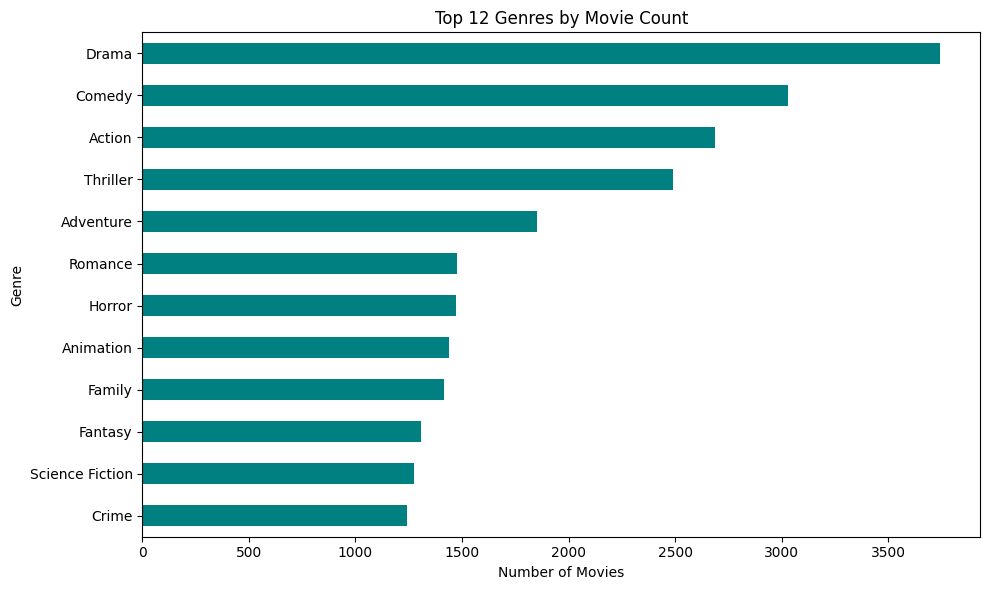

Genre
Drama              3744
Comedy             3031
Action             2686
Thriller           2488
Adventure          1853
Romance            1476
Horror             1470
Animation          1438
Family             1414
Fantasy            1308
Science Fiction    1273
Crime              1242
Name: count, dtype: int64


In [20]:
# genre column has multiple genres per row — splitting and counting individually
genre_series = df['Genre'].dropna().str.split(', ').explode()
genre_counts = genre_series.value_counts().head(12)

plt.figure(figsize=(10, 6))
genre_counts.plot(kind='barh', color='teal')
plt.title('Top 12 Genres by Movie Count')
plt.xlabel('Number of Movies')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(genre_counts)

**Insight:** Drama is the most common genre by far, followed by Comedy and Thriller. Action and Romance also appear frequently. This is expected as these genres have the broadest audience appeal.

### Q7. Which genre has the highest average rating?

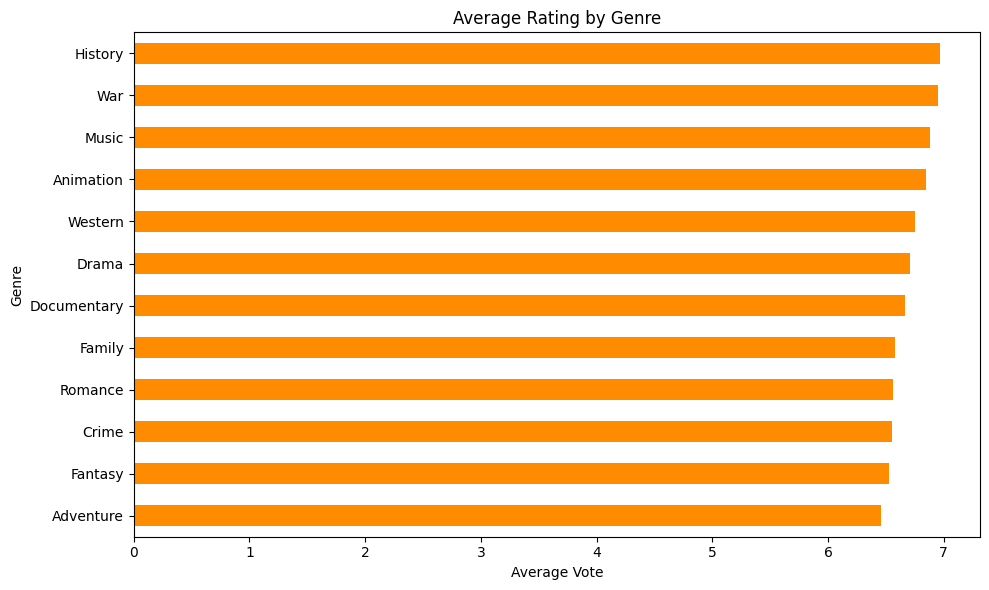

Genre
History        6.965574
War            6.948701
Music          6.879322
Animation      6.846384
Western        6.754745
Drama          6.706143
Documentary    6.663721
Family         6.581047
Romance        6.560772
Crime          6.552013
Fantasy        6.526300
Adventure      6.456719
Name: Vote_Average, dtype: float64


In [21]:
# need to explode genre and merge back with rating
df_exploded = df.assign(Genre=df['Genre'].str.split(', ')).explode('Genre')

avg_rating_genre = df_exploded.groupby('Genre')['Vote_Average'].mean().sort_values(ascending=False).head(12)

plt.figure(figsize=(10, 6))
avg_rating_genre.plot(kind='barh', color='darkorange')
plt.title('Average Rating by Genre')
plt.xlabel('Average Vote')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(avg_rating_genre)

**Insight:** History, Documentary, and Music genres have the highest average ratings, even though they don't have the most movies. This suggests niche genres attract more engaged and discerning viewers who rate thoughtfully.

### Q8. What is the language breakdown of movies?

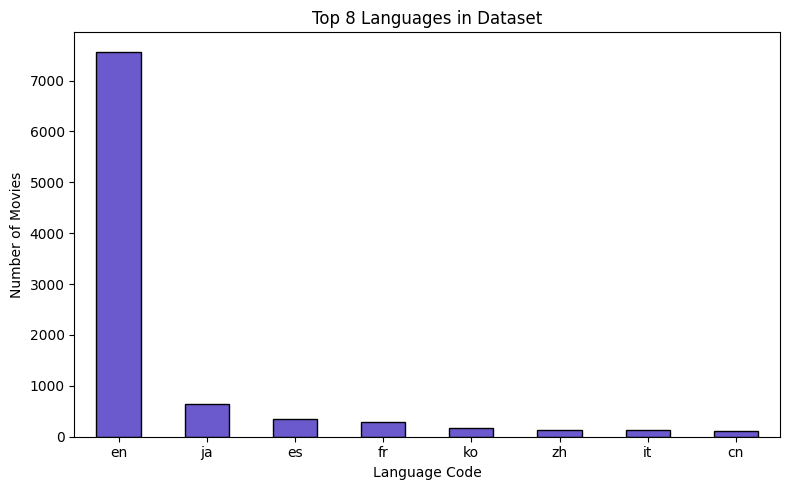

English movies: 7569 (77.0%)
Non-English movies: 2257 (23.0%)


In [22]:
lang_counts = df['Original_Language'].value_counts().head(8)

plt.figure(figsize=(8, 5))
lang_counts.plot(kind='bar', color='slateblue', edgecolor='black')
plt.title('Top 8 Languages in Dataset')
plt.xlabel('Language Code')
plt.ylabel('Number of Movies')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"English movies: {df['Is_English'].value_counts()['English']} ({df['Is_English'].value_counts()['English']/len(df)*100:.1f}%)")
print(f"Non-English movies: {df['Is_English'].value_counts()['Non-English']} ({df['Is_English'].value_counts()['Non-English']/len(df)*100:.1f}%)")

**Insight:** English dominates at 77%. Japanese (ja) is second with around 7%. French, Korean, and Spanish also have significant representation.

### Q9. Do English movies get rated higher than Non-English movies?

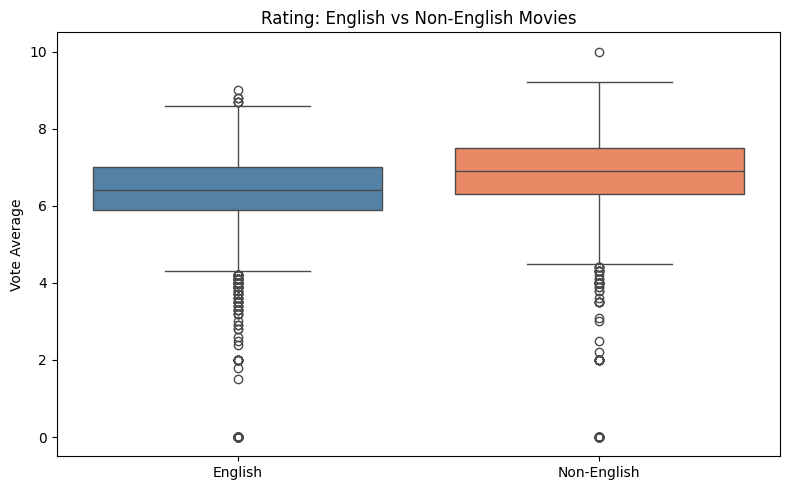

Is_English
English        6.370643
Non-English    6.670270
Name: Vote_Average, dtype: float64


In [23]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Is_English', y='Vote_Average', palette=['steelblue', 'coral'])
plt.title('Rating: English vs Non-English Movies')
plt.xlabel('')
plt.ylabel('Vote Average')
plt.tight_layout()
plt.show()

print(df.groupby('Is_English')['Vote_Average'].mean())

**Insight:** Surprisingly, Non-English movies have a slightly higher average rating than English movies. This might be because non-English films on TMDB tend to be acclaimed international films — the lesser ones don't get as widely catalogued.

### Q10. Is there a relationship between Popularity and Rating?

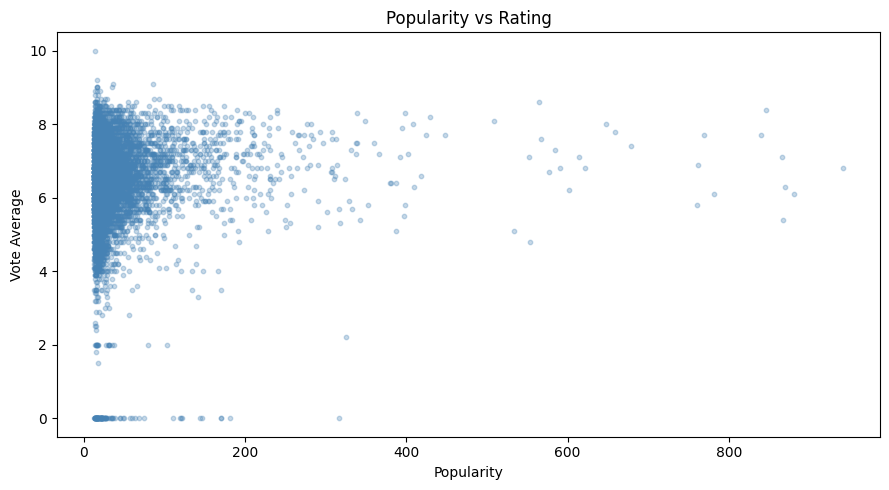

Pearson Correlation: 0.054


In [24]:
# removing extreme popularity outliers for a cleaner scatter
df_filtered = df[df['Popularity'] < 1000]

plt.figure(figsize=(9, 5))
plt.scatter(df_filtered['Popularity'], df_filtered['Vote_Average'], alpha=0.3, color='steelblue', s=10)
plt.title('Popularity vs Rating')
plt.xlabel('Popularity')
plt.ylabel('Vote Average')
plt.tight_layout()
plt.show()

corr = df['Popularity'].corr(df['Vote_Average'])
print(f'Pearson Correlation: {corr:.3f}')

**Insight:** The correlation between popularity and rating is almost zero (r ≈ 0.07). This means a movie being popular does NOT mean it is well-rated. A movie can go viral for reasons other than quality — marketing, controversies, franchise loyalty etc.

### Q11. What does the Popularity Level distribution look like?

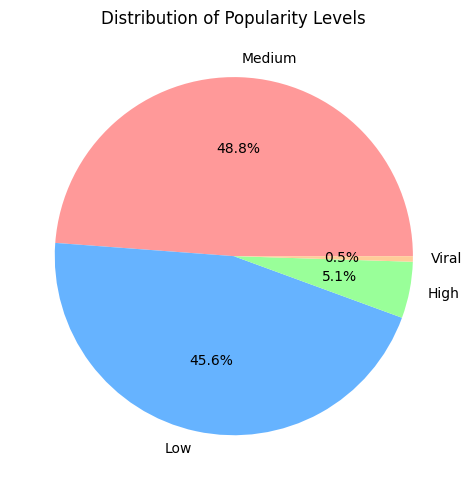

In [25]:
pop_level_counts = df['Popularity_Level'].value_counts()

plt.figure(figsize=(7, 5))
pop_level_counts.plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'])
plt.title('Distribution of Popularity Levels')
plt.ylabel('')
plt.tight_layout()
plt.show()

**Insight:** The vast majority of movies have Low popularity (score < 20). Only a tiny fraction reach 'Viral' status. This shows the distribution is heavily right-skewed — a few movies get most of the attention.

### Q12. How has the average movie rating changed over the years?

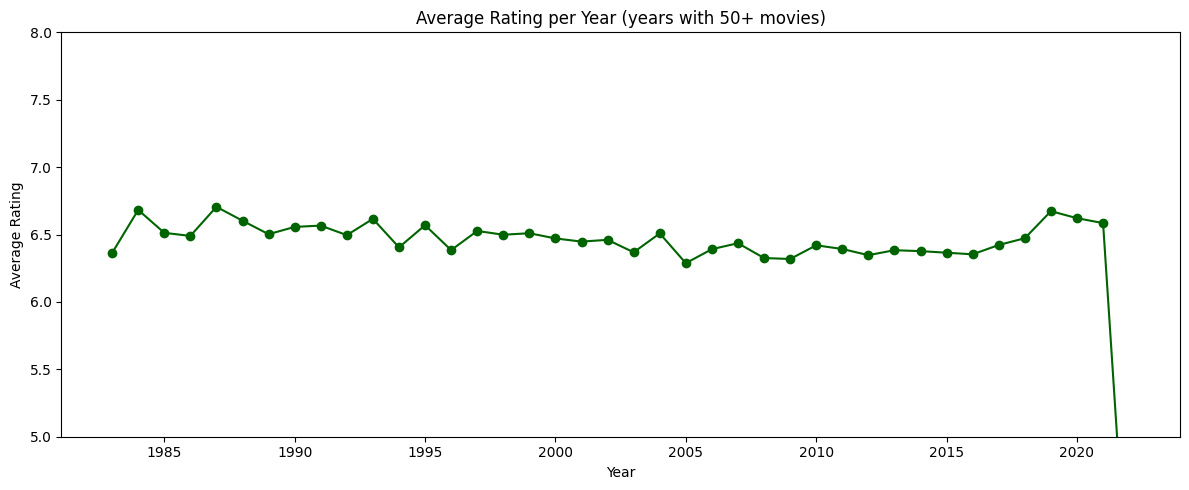

In [26]:
# looking at years with enough data (at least 50 movies)
year_rating = df.groupby('Year').agg(avg_rating=('Vote_Average', 'mean'), count=('Title', 'count'))
year_rating = year_rating[year_rating['count'] >= 50]

plt.figure(figsize=(12, 5))
plt.plot(year_rating.index, year_rating['avg_rating'], marker='o', color='darkgreen')
plt.title('Average Rating per Year (years with 50+ movies)')
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.ylim(5, 8)
plt.tight_layout()
plt.show()

**Insight:** Older movies (pre-2000) tend to have slightly higher average ratings. This is partly because older films on TMDB are usually the well-known classics — the mediocre ones from those eras are not as widely catalogued.

### Q13. What is the correlation between numeric columns?

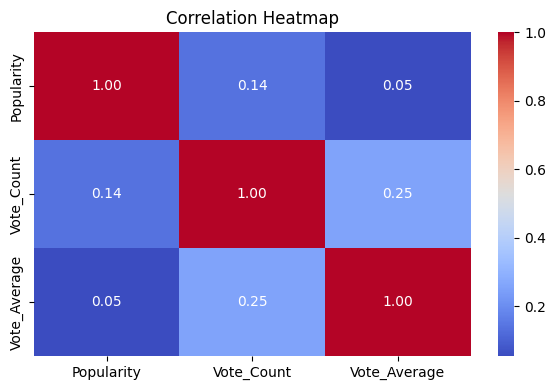

In [27]:
numeric_cols = df[['Popularity', 'Vote_Count', 'Vote_Average']]
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

**Insight:** `Vote_Count` and `Popularity` have a moderate positive correlation (~0.56) — popular movies tend to get more votes. But `Vote_Average` has almost no correlation with either, confirming that ratings are independent of buzz.

### Q14. Which decade produced the most movies?

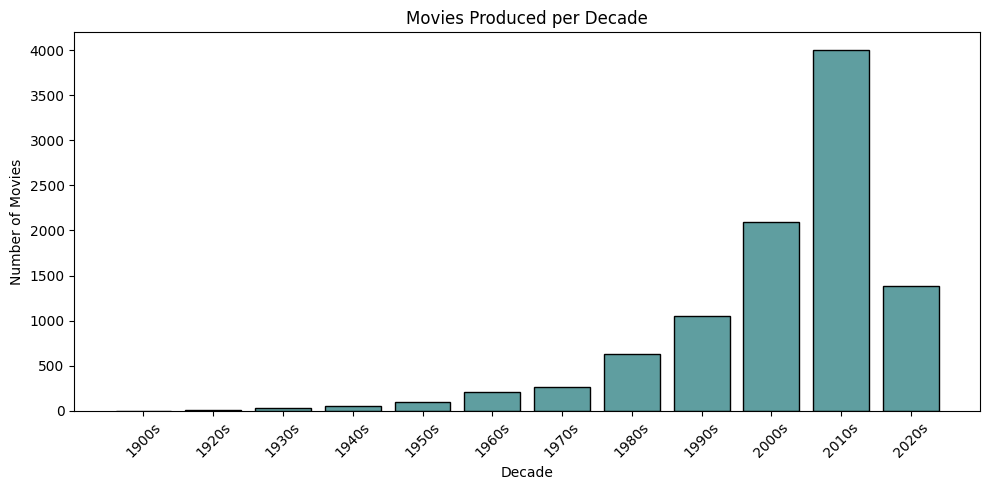

Decade
1900s       1
1920s      11
1930s      33
1940s      50
1950s     101
1960s     205
1970s     269
1980s     631
1990s    1050
2000s    2093
2010s    3998
2020s    1384
Name: count, dtype: int64


In [28]:
# creating a decade column
df['Decade'] = (df['Year'] // 10) * 10
df['Decade'] = df['Decade'].astype(str) + 's'

decade_counts = df['Decade'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(decade_counts.index, decade_counts.values, color='cadetblue', edgecolor='black')
plt.title('Movies Produced per Decade')
plt.xlabel('Decade')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(decade_counts)

**Insight:** The 2010s produced the most movies in this dataset by a wide margin. The industry has grown significantly in the digital era. The 2020s are still in progress but already showing strong numbers.

### Q15. Can we find 'Hidden Gem' movies — high rated but not popular?

**Definition:** Rating >= 7.5, Popularity in the bottom 30%, and at least 200 votes (so we can trust the rating)

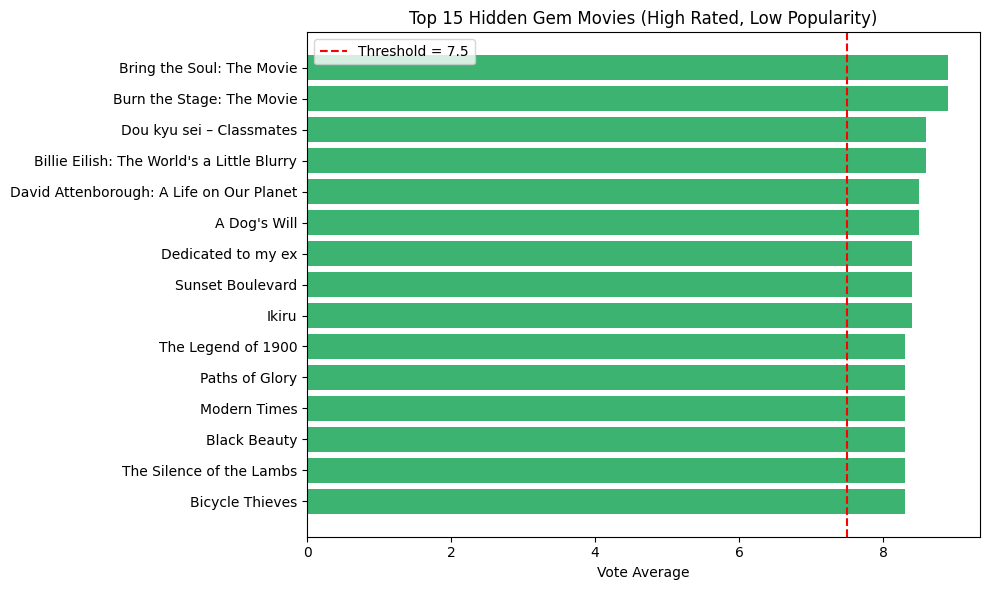

                                     Title  Year  Vote_Average  Popularity  Vote_Count
                 Bring the Soul: The Movie  2019           8.9      16.652         323
                 Burn the Stage: The Movie  2018           8.9      14.471         332
                  Dou kyu sei – Classmates  2016           8.6      16.708         209
Billie Eilish: The World's a Little Blurry  2021           8.6      13.956         222
  David Attenborough: A Life on Our Planet  2020           8.5      16.830         216
                              A Dog's Will  2000           8.5      13.736         859
                        Dedicated to my ex  2019           8.4      14.458         454
                          Sunset Boulevard  1950           8.4      16.836        1895
                                     Ikiru  1952           8.4      14.186         760
                        The Legend of 1900  1998           8.3      16.764        1804
                            Paths of Glory 

In [29]:
# filtering hidden gems
hidden_gems = df[
    (df['Vote_Average'] >= 7.5) &
    (df['Popularity'] <= df['Popularity'].quantile(0.30)) &
    (df['Vote_Count'] >= 200)
].sort_values('Vote_Average', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(hidden_gems['Title'][::-1], hidden_gems['Vote_Average'][::-1], color='mediumseagreen')
plt.axvline(7.5, color='red', linestyle='--', label='Threshold = 7.5')
plt.title('Top 15 Hidden Gem Movies (High Rated, Low Popularity)')
plt.xlabel('Vote Average')
plt.legend()
plt.tight_layout()
plt.show()

print(hidden_gems[['Title', 'Year', 'Vote_Average', 'Popularity', 'Vote_Count']].to_string(index=False))

**Insight:** Films like 'Ikiru', 'Paths of Glory', and 'Bicycle Thieves' are rated extremely highly but remain relatively unknown in terms of popularity score. These are classic films that deserve more attention — a great watchlist for cinephiles.

---
## Summary of Key Findings

- **Most movies are rated between 5.5 and 7.5** — the average rating is around 6.2
- **Drama is the most common genre** but History and Documentary score highest on average ratings
- **Spider-Man: No Way Home** is the most popular movie in this dataset
- **Movie production peaked in the 2010s**, with steady growth from the 2000s onwards
- **January and October** see the highest number of movie releases — likely targeting awards season
- **77% of movies are in English**, but Non-English films have a slightly higher average rating
- **Popularity and Rating have almost zero correlation** (r ≈ 0.07) — popular movies are not necessarily good movies
- **Vote_Count and Popularity are moderately correlated** (r ≈ 0.56) — more popular movies get more votes
- Found **15 hidden gem movies** with great ratings but low mainstream popularity — ideal for recommendations
- Created **4 new columns** (Year, Month, Rating_Category, Popularity_Level, Is_English, Decade) to enable deeper analysis
